# 1. Cellwise Euler vs. the implemented general Volterra scheme

This cell checks the **same approximative scheme** that is implemented by `volterra_vsig`, not the exact continuous Volterra equation.

For a coarse grid $0=t_0<\cdots<t_J=T$, the implemented general scheme computes

$$
\widehat V_j
=
\mathbf 1
+
\sum_{i=0}^{j}
\widehat V_{i-1}
\otimes
\mathcal E_{t_i,t_{i+1}}^{t_{j+1}}(\Delta Y_i),
\qquad
\widehat V_{-1}=\mathbf 1.
$$

The cellwise Euler reference uses the **same frozen left-point history** $\widehat V_{i-1}$, but approximates the local cell contribution

$$
\mathcal E_{t_i,t_{i+1}}^{t_{j+1}}(\Delta Y_i)
$$

by an Euler discretization on a dyadic partition of the single cell $[t_i,t_{i+1}]$. Thus, increasing `dyadic_order` should converge to `volterra_vsig` on the same coarse grid. This validates the local fractional coefficients and the indexing of the implemented approximative algorithm.


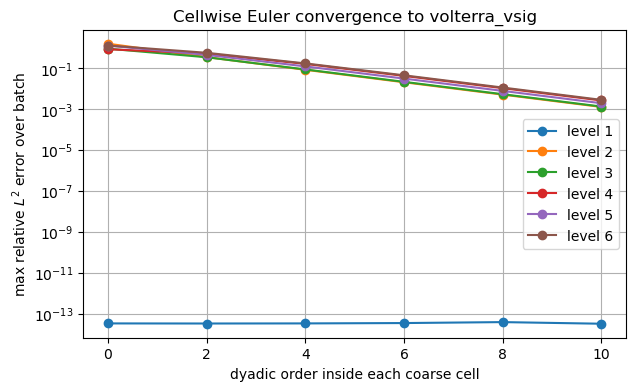

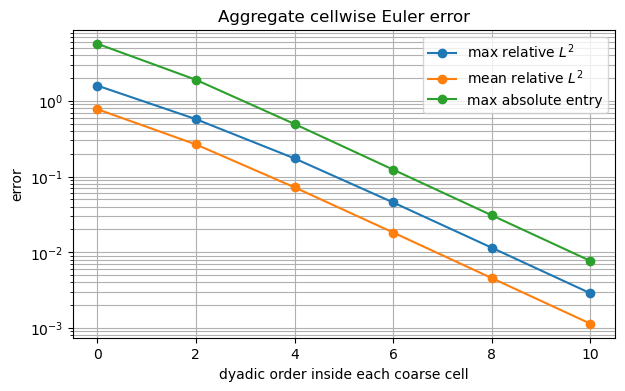

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from tensordev.util.random_paths import random_trigonometric_polynomial_paths
from tensordev.volterra import VolterraKernel, vsig
from cell_euler import fractional_cell_euler_vsig


dtype = jnp.float64
key = jax.random.PRNGKey(0)

beta = 0.75
T = 1.0
steps = 8
batch = 4
dim = 2
trunc = 6
dt = T / steps

dyadic_orders = [0, 2, 4, 6, 8, 10]

X = random_trigonometric_polynomial_paths(
    key,
    batch=batch,
    steps=steps,
    dim=dim,
    n_modes=4,
    scale=0.35,
    decay=1.5,
    horizon=T,
).astype(dtype)

A = jnp.eye(dim, dtype=dtype)[None, :, :]

kernel = VolterraKernel.fractional(
    beta=jnp.array([beta], dtype=dtype),
    A=A,
)

target = vsig(
    X,
    kernel=kernel,
    dt=dt,
    trunc=trunc,
    axis=1,
)

rows = []

for dyadic_order in dyadic_orders:
    approx = fractional_cell_euler_vsig(
        X,
        beta=beta,
        A=A,
        dt=dt,
        trunc=trunc,
        axis=1,
        dyadic_order=dyadic_order,
    )

    for level, (a, b) in enumerate(zip(target, approx)):
        aa = a.reshape((batch, -1))
        bb = b.reshape((batch, -1))
        diff = bb - aa

        abs_l2 = jnp.linalg.norm(diff, axis=-1)
        rel_l2 = abs_l2 / jnp.maximum(jnp.linalg.norm(aa, axis=-1), 1e-14)

        rows.append(
            {
                "dyadic_order": dyadic_order,
                "level": level,
                "mean_abs_l2": float(jnp.mean(abs_l2)),
                "max_abs_l2": float(jnp.max(abs_l2)),
                "mean_rel_l2": float(jnp.mean(rel_l2)),
                "max_rel_l2": float(jnp.max(rel_l2)),
                "max_abs_entry": float(jnp.max(jnp.abs(diff))),
            }
        )

df_cell_euler = pd.DataFrame(rows)
compact_cell_euler = (
    df_cell_euler[df_cell_euler["level"] > 0]
    .groupby("dyadic_order", as_index=False)
    .agg(
        max_rel_l2=("max_rel_l2", "max"),
        mean_rel_l2=("mean_rel_l2", "mean"),
        max_abs_entry=("max_abs_entry", "max"),
    )
)

fig, ax = plt.subplots(figsize=(7, 4))
for level in sorted(df_cell_euler["level"].unique()):
    if level == 0:
        continue
    sub = df_cell_euler[df_cell_euler["level"] == level]
    ax.semilogy(sub["dyadic_order"], sub["max_rel_l2"], marker="o", label=f"level {level}")
ax.set_xlabel("dyadic order inside each coarse cell")
ax.set_ylabel("max relative $L^2$ error over batch")
ax.set_title("Cellwise Euler convergence to volterra_vsig")
ax.grid(True, which="both")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(compact_cell_euler["dyadic_order"], compact_cell_euler["max_rel_l2"], marker="o", label="max relative $L^2$")
ax.semilogy(compact_cell_euler["dyadic_order"], compact_cell_euler["mean_rel_l2"], marker="o", label="mean relative $L^2$")
ax.semilogy(compact_cell_euler["dyadic_order"], compact_cell_euler["max_abs_entry"], marker="o", label="max absolute entry")
ax.set_xlabel("dyadic order inside each coarse cell")
ax.set_ylabel("error")
ax.set_title("Aggregate cellwise Euler error")
ax.grid(True, which="both")
ax.legend()
plt.show()


# 2. FSSK rough approximation vs. predictor-corrector reference

This cell compares a finite-state-space approximation of the fractional kernel to a direct predictor-corrector reference for the **true tensor-valued Volterra equation**.

The predictor-corrector target approximates

$$
V_t^{(0)}=1,
\qquad
V_t^{(n)}
=
\int_0^t
K_\beta(t-s)\,
V_s^{(n-1)}\otimes dY_s,
\qquad
K_\beta(u)=\frac{u^{\beta-1}}{\Gamma(\beta)}.
$$

The FSSK approximation replaces the fractional kernel by an exponential sum

$$
K_\beta(u)
\approx
\sum_{r=1}^R w_r e^{-\lambda_r u},
$$

and computes the corresponding finite-state-space signature. The error therefore measures the combined effect of the exponential-kernel approximation, the FSSK coefficient quadrature, and the finite predictor-corrector reference tolerance.


X.shape: (4, 9, 2)
PC target level shapes: [(4, 1), (4, 2), (4, 4), (4, 8), (4, 16), (4, 32), (4, 64)]


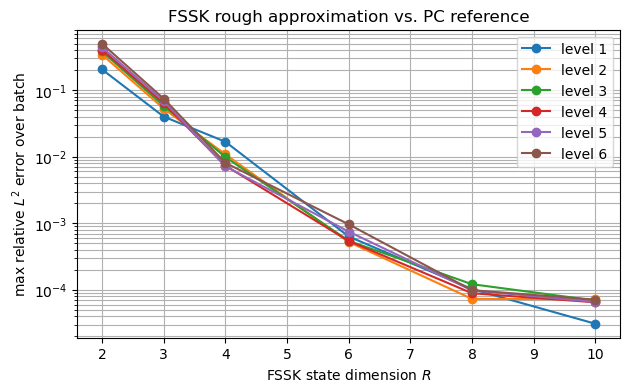

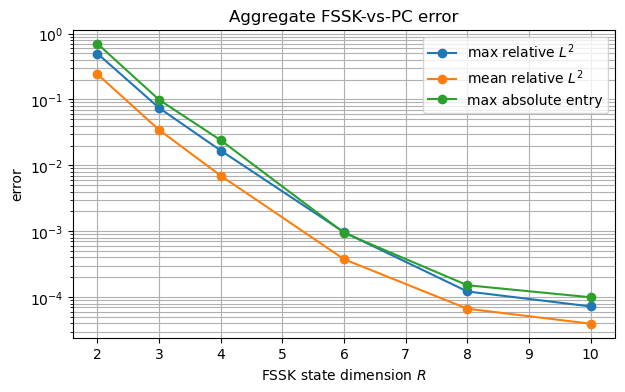

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from tensordev.util.random_paths import random_trigonometric_polynomial_paths
from tensordev.sss import StateSpaceSignature
from tensordev.sss.rough_approx import fractional_fssk
from predictor_corrector import fractional_pc_vsig


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

dtype = jnp.float64
key = jax.random.PRNGKey(42)

beta = 0.75
T = 1.0

steps = 8
batch = 4
dim = 2
trunc = 6

dt = T / steps

# R = number of exponential factors / FSSK state dimension.
R_values = [2, 3, 4, 6, 8, 10]

# Predictor-corrector refinement inside the fractional reference solver.
pc_dyadic_order = 7

# FSSK coefficient contour quadrature order.
coef_quad_order = 64


# ---------------------------------------------------------------------
# Random paths
# ---------------------------------------------------------------------

X = random_trigonometric_polynomial_paths(
    key,
    batch=batch,
    steps=steps,
    dim=dim,
    n_modes=4,
    scale=0.35,
    decay=1.5,
    horizon=T,
).astype(dtype)

A = jnp.eye(dim, dtype=dtype)[None, :, :]  # q=1, m=d

print("X.shape:", X.shape)


# ---------------------------------------------------------------------
# Predictor-corrector target: true fractional tensor-valued Volterra equation
# ---------------------------------------------------------------------

pc_target = fractional_pc_vsig(
    X,
    beta=beta,
    A=A,
    dt=dt,
    trunc=trunc,
    axis=1,
    increment_input=False,
    dyadic_order=pc_dyadic_order,
    scheme="pc",
)

print("PC target level shapes:", [z.shape for z in pc_target])


# ---------------------------------------------------------------------
# Error helpers
# ---------------------------------------------------------------------

def _flatten_batch_level(z):
    z = jnp.asarray(z)
    return z.reshape((z.shape[0], -1))


def level_error_rows(ref, got, *, R):
    rows = []

    for level, (a, b) in enumerate(zip(ref, got)):
        aa = _flatten_batch_level(a)
        bb = _flatten_batch_level(b)

        diff = bb - aa
        abs_l2 = jnp.linalg.norm(diff, axis=-1)
        ref_l2 = jnp.linalg.norm(aa, axis=-1)
        rel_l2 = abs_l2 / jnp.maximum(ref_l2, 1e-14)

        rows.append(
            {
                "R": R,
                "level": level,
                "pc_shape": tuple(a.shape),
                "fssk_shape": tuple(b.shape),
                "mean_abs_l2": float(jnp.mean(abs_l2)),
                "max_abs_l2": float(jnp.max(abs_l2)),
                "mean_rel_l2": float(jnp.mean(rel_l2)),
                "max_rel_l2": float(jnp.max(rel_l2)),
                "max_abs_entry": float(jnp.max(jnp.abs(diff))),
            }
        )

    return rows


# ---------------------------------------------------------------------
# Compare FSSK rough approximations against PC target
# ---------------------------------------------------------------------

rows = []

for R in R_values:
    fssk_kernel = fractional_fssk(
        beta=beta,
        R=R,
        A=A,
        T=T,
        coef_quad_order=coef_quad_order,
        dtype=dtype,
    )

    fssk_sig = StateSpaceSignature(
        kernel=fssk_kernel,
        trunc=trunc,
    ).vsig(
        X,
        dt=dt,
        axis=1,
        increment_input=False,
    )

    rows.extend(level_error_rows(pc_target, fssk_sig, R=R))

df_fssk_pc = pd.DataFrame(rows)
compact_fssk_pc = (
    df_fssk_pc[df_fssk_pc["level"] > 0]
    .groupby("R", as_index=False)
    .agg(
        max_rel_l2=("max_rel_l2", "max"),
        mean_rel_l2=("mean_rel_l2", "mean"),
        max_abs_entry=("max_abs_entry", "max"),
    )
)

fig, ax = plt.subplots(figsize=(7, 4))
for level in sorted(df_fssk_pc["level"].unique()):
    if level == 0:
        continue
    sub = df_fssk_pc[df_fssk_pc["level"] == level]
    ax.semilogy(sub["R"], sub["max_rel_l2"], marker="o", label=f"level {level}")
ax.set_xlabel("FSSK state dimension $R$")
ax.set_ylabel("max relative $L^2$ error over batch")
ax.set_title("FSSK rough approximation vs. PC reference")
ax.grid(True, which="both")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(compact_fssk_pc["R"], compact_fssk_pc["max_rel_l2"], marker="o", label="max relative $L^2$")
ax.semilogy(compact_fssk_pc["R"], compact_fssk_pc["mean_rel_l2"], marker="o", label="mean relative $L^2$")
ax.semilogy(compact_fssk_pc["R"], compact_fssk_pc["max_abs_entry"], marker="o", label="max absolute entry")
ax.set_xlabel("FSSK state dimension $R$")
ax.set_ylabel("error")
ax.set_title("Aggregate FSSK-vs-PC error")
ax.grid(True, which="both")
ax.legend()
plt.show()
